In [1]:
#pip install torch

In [2]:
#pip install torchsummary

In [3]:
#pip install pytorch-ignite

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from collections import defaultdict

In [5]:
df = pd.read_csv("../datasets/CLF/HTRU_2.csv")

In [6]:
df.head()

,140.5625,55.68378214,-0.234571412,-0.699648398,3.199832776,19.11042633,7.975531794,74.24222492,0
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [7]:
column_names = [
    "ip_mean",
    "ip_std",
    "ip_kurtosis",
    "ip_skewness",
    "dm_mean",
    "dm_std",
    "dm_kurtosis",
    "dm_skewness",
    "signal",
]
df.columns = column_names
df.head()

,ip_mean,ip_std,ip_kurtosis,ip_skewness,dm_mean,dm_std,dm_kurtosis,dm_skewness,signal
0,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
1,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
2,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
3,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
4,93.570312,46.698114,0.531905,0.416721,1.636288,14.545074,10.621748,131.394004,0


In [8]:
df.isnull().sum()

ip_mean        0
ip_std         0
ip_kurtosis    0
ip_skewness    0
dm_mean        0
dm_std         0
dm_kurtosis    0
dm_skewness    0
signal         0
dtype: int64

In [9]:
df.dtypes

ip_mean        float64
ip_std         float64
ip_kurtosis    float64
ip_skewness    float64
dm_mean        float64
dm_std         float64
dm_kurtosis    float64
dm_skewness    float64
signal           int64
dtype: object

In [10]:
X = df.drop('signal', axis=1)  # Features
y = df['signal']

In [11]:
Counter(y)

Counter({0: 16258, 1: 1639})

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [13]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=100, stratify=y)

In [14]:
# creates validation set
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [17]:
from sklearn.decomposition import PCA

In [18]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
    plt.show()

In [19]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
print(X_train.shape, X_pca.shape)

(10737, 8) (10737, 2)


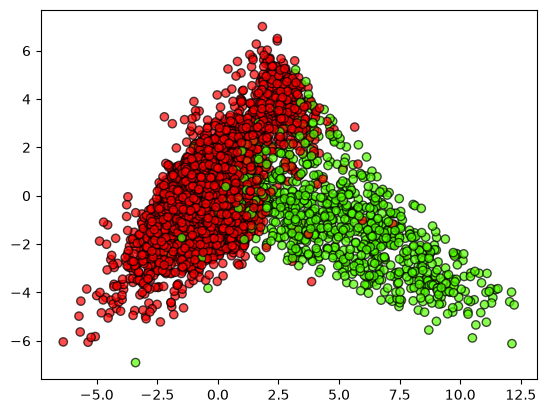

In [20]:
plot_pca(X_pca,y_train)

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader

from ignite.metrics import Accuracy, Loss
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

c:\Users\david\anaconda3\envs\pytorch_gpu\Lib\site-packages\ignite\handlers\checkpoint.py:16: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


In [22]:
print(torch.cuda.is_available())

True


In [23]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"

In [24]:
# Spostiamo i tensori direttamente nella memoria della GPU
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

# Creazione Dataset e DataLoader (invariata)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
# creates tensor dataset (can be later loaded)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [26]:
# creates data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [27]:
class CustomModel(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(CustomModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)
        self.relu = nn.ReLU()
        #self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [28]:
# define hyperparameters
n_classes = len(np.unique(y_train))
input_size = X_train.shape[1]
hidden_size1 = 128
hidden_size2 = 64
output_size = n_classes

In [29]:
# instanciates model
model = CustomModel(input_size, hidden_size1, hidden_size2, output_size)

In [30]:
summary(model, input_size=(input_size,), device = device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]           1,152
              ReLU-2                  [-1, 128]               0
            Linear-3                   [-1, 64]           8,256
              ReLU-4                   [-1, 64]               0
            Linear-5                    [-1, 2]             130
Total params: 9,538
Trainable params: 9,538
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


In [31]:
# optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [32]:
from ignite.metrics import Accuracy, Loss, ROC_AUC, Fbeta, MatthewsCorrCoef, Precision, Recall

# Trasformazione per ROC_AUC: prende probabilità della classe 1
def roc_transform(output):
    y_pred, y = output
    y_probs = torch.softmax(y_pred, dim=1)
    return (y_probs[:, 1], y)   # solo colonna 1

# Trasformazione per metriche che richiedono classi predette (non probabilità)
def class_transform(output):
    y_pred, y = output
    y_pred_class = torch.argmax(y_pred, dim=1)
    return (y_pred_class, y)

val_metrics = {
    "loss": Loss(criterion),
    "accuracy": Accuracy(output_transform=class_transform),
    "roc_auc": ROC_AUC(output_transform=roc_transform),
    "f1": Fbeta(beta=1, average='macro', output_transform=class_transform),
    "mcc": MatthewsCorrCoef(output_transform=class_transform),
    "precision": Precision(average='macro', output_transform=class_transform),
    "recall": Recall(average='macro', output_transform=class_transform)
}

In [33]:
# ignite trainer
trainer = create_supervised_trainer(model, optimizer, criterion, device)

# ignite train and validation evaluators
train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

# Crea le history con tutte le chiavi delle metriche (più 'loss' che è già presente)
training_history = {key: [] for key in val_metrics.keys()}
validation_history = {key: [] for key in val_metrics.keys()}

In [34]:
log_interval = 100

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    # Salva ogni metrica nella history (accuracy e f1 in percentuale, loss no)
    for key, value in metrics.items():
        if key != 'loss':
            training_history[key].append(value * 100)
        else:
            training_history[key].append(value)
    # Stampa a schermo (scegli le metriche più importanti)
    print(f"Training Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    for key, value in metrics.items():
        if key != 'loss':
            validation_history[key].append(value * 100)
        else:
            validation_history[key].append(value)
    print(f"Validation Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

In [35]:
trainer.run(train_loader, max_epochs=100)

Epoch[1], Iter[100] Loss: 0.0667
Epoch[1], Iter[200] Loss: 0.0224
Epoch[1], Iter[300] Loss: 0.2021
Training Results - Epoch[1] Acc: 0.98%  Loss: 0.0747  F1: 0.8775  ROC_AUC: 0.9721  MCC: 0.8687  Prec: 0.9629  Rec: 0.9075
Validation Results - Epoch[1] Acc: 0.98%  Loss: 0.0807  F1: 0.8661  ROC_AUC: 0.9716  MCC: 0.8537  Prec: 0.9398  Rec: 0.9143
Epoch[2], Iter[400] Loss: 0.0507
Epoch[2], Iter[500] Loss: 0.0113
Epoch[2], Iter[600] Loss: 0.1015
Training Results - Epoch[2] Acc: 0.98%  Loss: 0.0710  F1: 0.8836  ROC_AUC: 0.9753  MCC: 0.8745  Prec: 0.9614  Rec: 0.9144
Validation Results - Epoch[2] Acc: 0.98%  Loss: 0.0769  F1: 0.8774  ROC_AUC: 0.9731  MCC: 0.8659  Prec: 0.9454  Rec: 0.9208
Epoch[3], Iter[700] Loss: 0.0067
Epoch[3], Iter[800] Loss: 0.0300
Epoch[3], Iter[900] Loss: 0.0468
Epoch[3], Iter[1000] Loss: 0.0508
Training Results - Epoch[3] Acc: 0.98%  Loss: 0.0690  F1: 0.8829  ROC_AUC: 0.9773  MCC: 0.8738  Prec: 0.9618  Rec: 0.9134
Validation Results - Epoch[3] Acc: 0.98%  Loss: 0.0750 

State:
	iteration: 33600
	epoch: 100
	epoch_length: 336
	max_epochs: 100
	max_iters: <class 'NoneType'>
	output: 0.12009838223457336
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

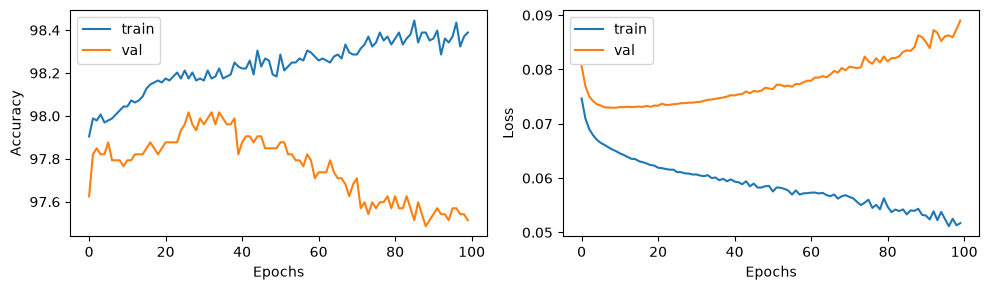

In [36]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
axes[0].plot(training_history['accuracy'], label='train')
axes[0].plot(validation_history['accuracy'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(training_history['loss'], label='train')
axes[1].plot(validation_history['loss'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
fig.tight_layout()

plt.show()

# Early Stopping

In [37]:
from ignite.handlers import EarlyStopping, ModelCheckpoint
from ignite.contrib.handlers import global_step_from_engine

In [38]:
# model + optimizer + criterion
model = CustomModel(input_size, hidden_size1, hidden_size2, output_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ignite trainer + evaluators
trainer = create_supervised_trainer(model, optimizer, criterion, device)



train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)


# Crea le history con tutte le chiavi delle metriche (più 'loss' che è già presente)
training_history = {key: [] for key in val_metrics.keys()}
validation_history = {key: [] for key in val_metrics.keys()}

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    # Salva ogni metrica nella history (accuracy e f1 in percentuale, loss no)
    for key, value in metrics.items():
        if key != 'loss':
            training_history[key].append(value * 100)
        else:
            training_history[key].append(value)
    # Stampa a schermo (scegli le metriche più importanti)
    print(f"Training Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    for key, value in metrics.items():
        if key != 'loss':
            validation_history[key].append(value * 100)
        else:
            validation_history[key].append(value)
    print(f"Validation Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

best_f1 = 0.0
best_path = 'models/best_Early.pt'

@val_evaluator.on(Events.EPOCH_COMPLETED)
def save_best_model(engine):
    global best_f1
    f1 = engine.state.metrics['f1']
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), best_path)
        print(f"✅ Nuovo miglior modello salvato (F1-macro: {f1:.4f} all'epoca {trainer.state.epoch})")

In [39]:
# return current value of any metric defined in val_metrics
def score_function(engine):
    return engine.state.metrics['roc_auc']   # Più alto è meglio

In [40]:
# define early stopping and model checkpoint
handler = EarlyStopping(patience=15, score_function=score_function, trainer=trainer)


# Attach early stopping and model checkpoint to the trainer
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)

In [41]:
trainer.run(train_loader, max_epochs=150)

Epoch[1], Iter[100] Loss: 0.0756
Epoch[1], Iter[200] Loss: 0.0235
Epoch[1], Iter[300] Loss: 0.2118
Training Results - Epoch[1] Acc: 0.98%  Loss: 0.0745  F1: 0.8768  ROC_AUC: 0.9725  MCC: 0.8680  Prec: 0.9633  Rec: 0.9065
✅ Nuovo miglior modello salvato (F1-macro: 0.8671 all'epoca 1)
Validation Results - Epoch[1] Acc: 0.98%  Loss: 0.0805  F1: 0.8671  ROC_AUC: 0.9698  MCC: 0.8550  Prec: 0.9424  Rec: 0.9131
Epoch[2], Iter[400] Loss: 0.0509
Epoch[2], Iter[500] Loss: 0.0100
Epoch[2], Iter[600] Loss: 0.0942
Training Results - Epoch[2] Acc: 0.98%  Loss: 0.0709  F1: 0.8820  ROC_AUC: 0.9752  MCC: 0.8731  Prec: 0.9626  Rec: 0.9120
✅ Nuovo miglior modello salvato (F1-macro: 0.8770 all'epoca 2)
Validation Results - Epoch[2] Acc: 0.98%  Loss: 0.0770  F1: 0.8770  ROC_AUC: 0.9718  MCC: 0.8657  Prec: 0.9466  Rec: 0.9195
Epoch[3], Iter[700] Loss: 0.0062
Epoch[3], Iter[800] Loss: 0.0274
Epoch[3], Iter[900] Loss: 0.0463
Epoch[3], Iter[1000] Loss: 0.0578
Training Results - Epoch[3] Acc: 0.98%  Loss: 0.069

2026-08-26 19:32:41,017 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Training Results - Epoch[32] Acc: 0.98%  Loss: 0.0616  F1: 0.8926  ROC_AUC: 0.9849  MCC: 0.8845  Prec: 0.9674  Rec: 0.9184
Validation Results - Epoch[32] Acc: 0.98%  Loss: 0.0746  F1: 0.8818  ROC_AUC: 0.9746  MCC: 0.8717  Prec: 0.9552  Rec: 0.9173


State:
	iteration: 10752
	epoch: 32
	epoch_length: 336
	max_epochs: 150
	max_iters: <class 'NoneType'>
	output: 0.19431103765964508
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

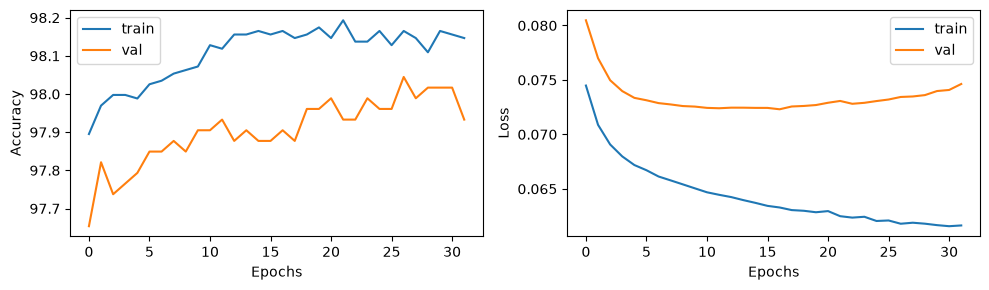

In [42]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
axes[0].plot(training_history['accuracy'], label='train')
axes[0].plot(validation_history['accuracy'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(training_history['loss'], label='train')
axes[1].plot(validation_history['loss'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
fig.tight_layout()

plt.show()

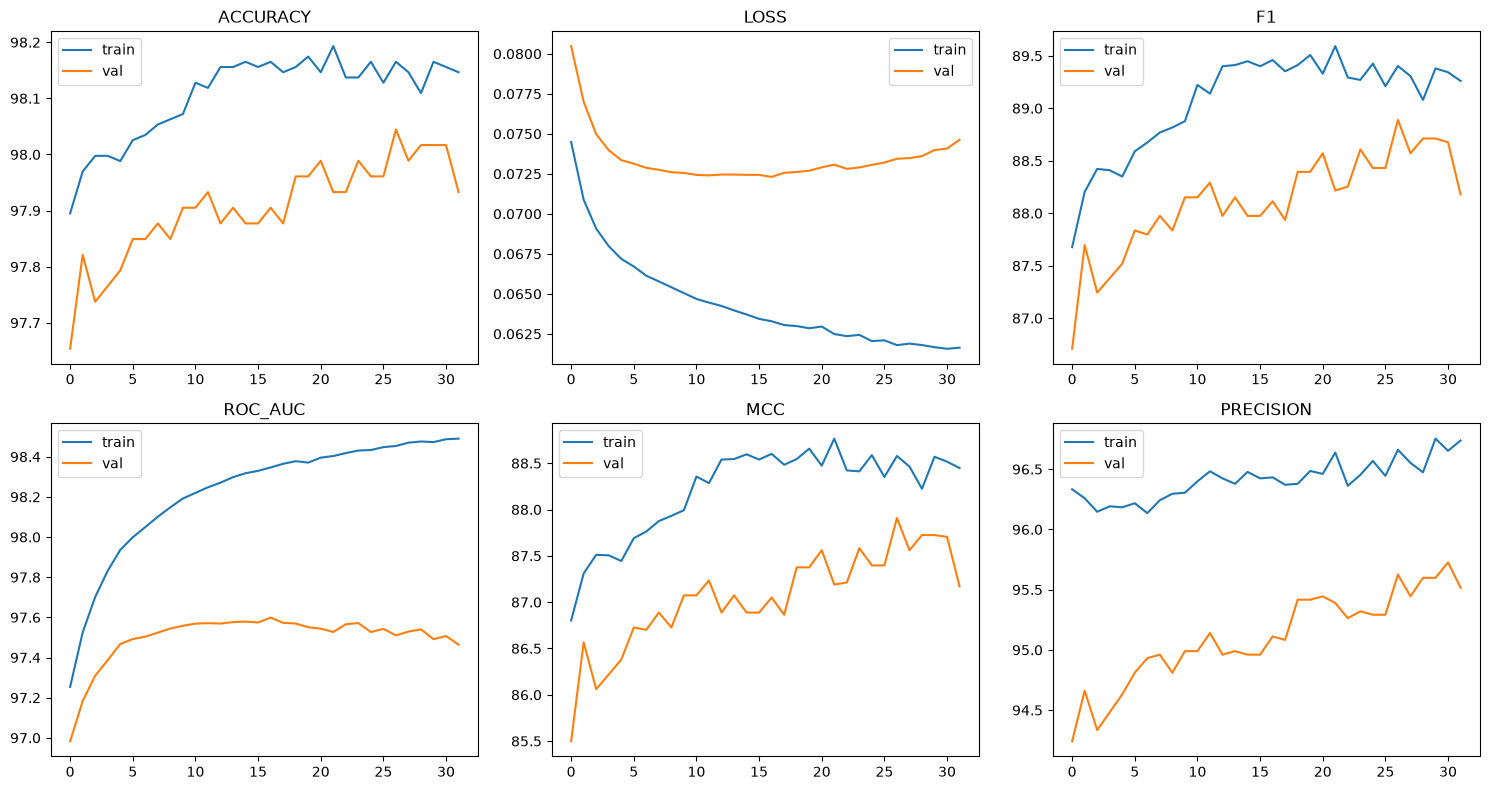

In [43]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics_to_plot = ['accuracy', 'loss', 'f1', 'roc_auc', 'mcc', 'precision']
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    ax.plot(training_history[metric], label='train')
    ax.plot(validation_history[metric], label='val')
    ax.set_title(metric.upper())
    ax.legend()
plt.tight_layout()
plt.show()

# L2 Regularization

In [44]:
class L2Model(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(L2Model, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

In [45]:
hidden_dim = 100

In [46]:
# model + optimizer + criterion
model = L2Model(input_size, hidden_dim, n_classes)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)
criterion = nn.CrossEntropyLoss()

# ignite trainer + evaluators
trainer = create_supervised_trainer(model, optimizer, criterion, device)


train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

# Crea le history con tutte le chiavi delle metriche (più 'loss' che è già presente)
training_history = {key: [] for key in val_metrics.keys()}
validation_history = {key: [] for key in val_metrics.keys()}

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    # Salva ogni metrica nella history (accuracy e f1 in percentuale, loss no)
    for key, value in metrics.items():
        if key != 'loss':
            training_history[key].append(value * 100)
        else:
            training_history[key].append(value)
    # Stampa a schermo (scegli le metriche più importanti)
    print(f"Training Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    for key, value in metrics.items():
        if key != 'loss':
            validation_history[key].append(value * 100)
        else:
            validation_history[key].append(value)
    print(f"Validation Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

best_f1 = 0.0
best_path = 'models/best_L2.pt'

@val_evaluator.on(Events.EPOCH_COMPLETED)
def save_best_model(engine):
    global best_f1
    f1 = engine.state.metrics['f1']
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), best_path)
        print(f"✅ Nuovo miglior modello salvato (F1-macro: {f1:.4f} all'epoca {trainer.state.epoch})")

In [47]:
# Define early stopping and model checkpoint
handler = EarlyStopping(patience=50, score_function=score_function, trainer=trainer)

val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)


In [48]:
trainer.run(train_loader, max_epochs=100)

Epoch[1], Iter[100] Loss: 0.0707
Epoch[1], Iter[200] Loss: 0.0314
Epoch[1], Iter[300] Loss: 0.1734
Training Results - Epoch[1] Acc: 0.98%  Loss: 0.0734  F1: 0.8846  ROC_AUC: 0.9738  MCC: 0.8750  Prec: 0.9578  Rec: 0.9180
✅ Nuovo miglior modello salvato (F1-macro: 0.8687 all'epoca 1)
Validation Results - Epoch[1] Acc: 0.98%  Loss: 0.0777  F1: 0.8687  ROC_AUC: 0.9738  MCC: 0.8562  Prec: 0.9379  Rec: 0.9186
Epoch[2], Iter[400] Loss: 0.0681
Epoch[2], Iter[500] Loss: 0.0142
Epoch[2], Iter[600] Loss: 0.1173
Training Results - Epoch[2] Acc: 0.98%  Loss: 0.0706  F1: 0.8897  ROC_AUC: 0.9763  MCC: 0.8804  Prec: 0.9595  Rec: 0.9217
✅ Nuovo miglior modello salvato (F1-macro: 0.8709 all'epoca 2)
Validation Results - Epoch[2] Acc: 0.98%  Loss: 0.0752  F1: 0.8709  ROC_AUC: 0.9750  MCC: 0.8584  Prec: 0.9371  Rec: 0.9214
Epoch[3], Iter[700] Loss: 0.0060
Epoch[3], Iter[800] Loss: 0.0353
Epoch[3], Iter[900] Loss: 0.0626
Epoch[3], Iter[1000] Loss: 0.0472
Training Results - Epoch[3] Acc: 0.98%  Loss: 0.069

2026-08-26 19:36:34,667 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Validation Results - Epoch[85] Acc: 0.98%  Loss: 0.0737  F1: 0.8663  ROC_AUC: 0.9764  MCC: 0.8527  Prec: 0.9252  Rec: 0.9275


State:
	iteration: 28560
	epoch: 85
	epoch_length: 336
	max_epochs: 100
	max_iters: <class 'NoneType'>
	output: 0.21428176760673523
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

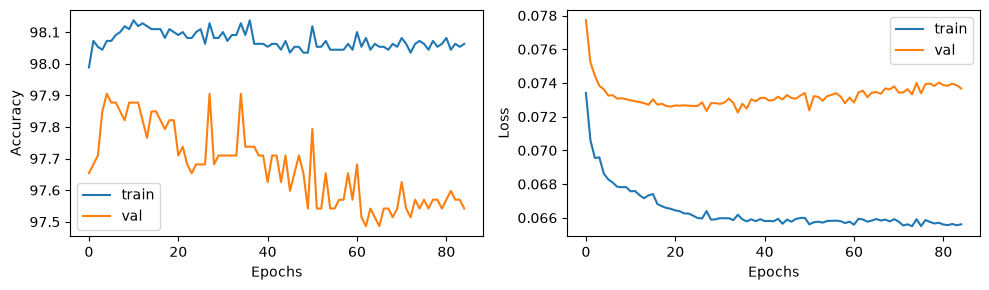

In [49]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
axes[0].plot(training_history['accuracy'], label='train')
axes[0].plot(validation_history['accuracy'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(training_history['loss'], label='train')
axes[1].plot(validation_history['loss'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
fig.tight_layout()

plt.show()

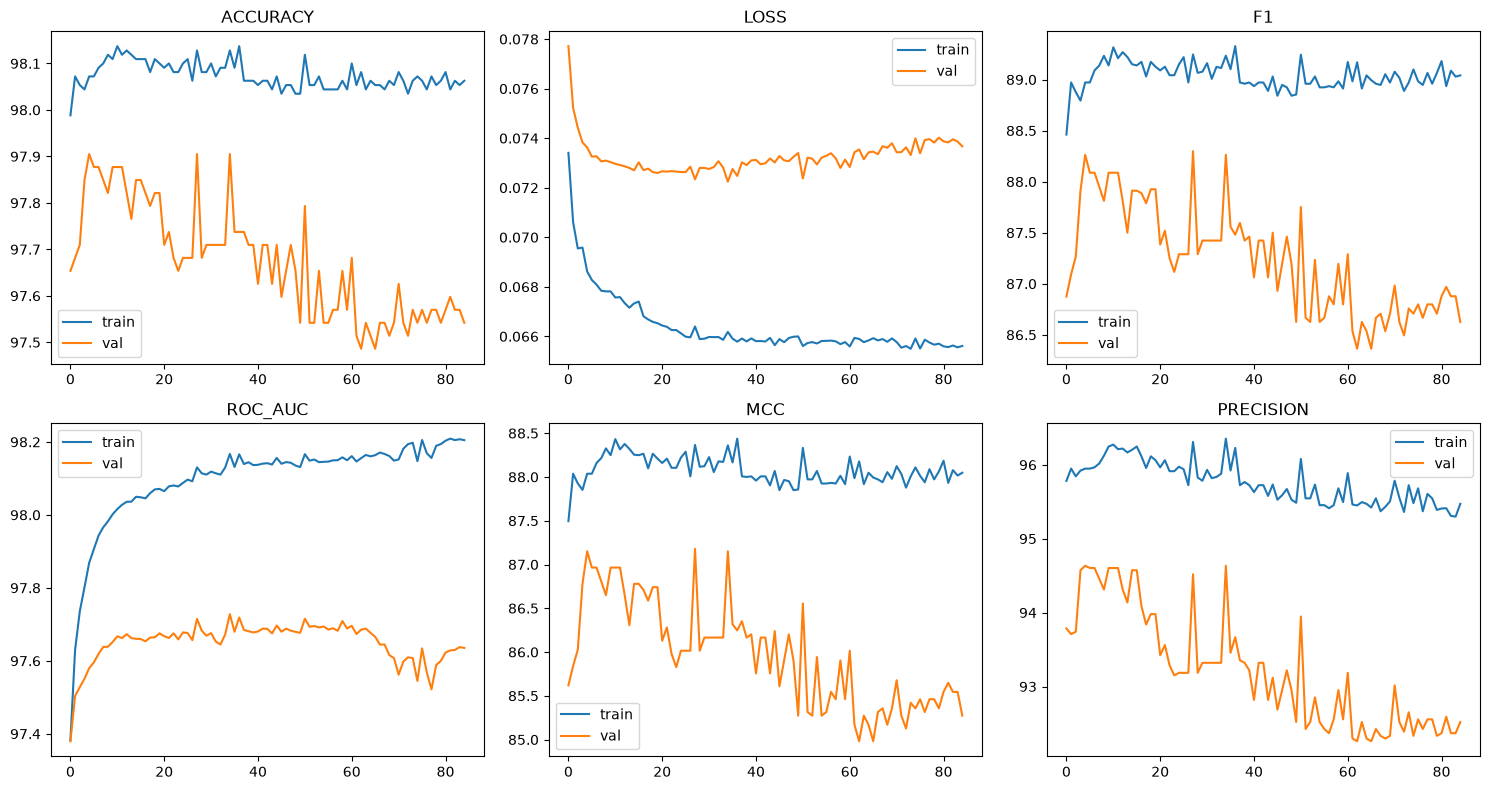

In [50]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics_to_plot = ['accuracy', 'loss', 'f1', 'roc_auc', 'mcc', 'precision']
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    ax.plot(training_history[metric], label='train')
    ax.plot(validation_history[metric], label='val')
    ax.set_title(metric.upper())
    ax.legend()
plt.tight_layout()
plt.show()

# DropOut

In [51]:
class DropoutModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_prob=0.1):
        super(DropoutModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout_prob)
        self.relu = nn.ReLU()
        self.fc4 = nn.Linear(hidden_dim, hidden_dim)
        self.fc5 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

In [52]:
# model + optimizer + criterion
model = DropoutModel(input_size, hidden_dim, n_classes, dropout_prob=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ignite trainer + evaluators
trainer = create_supervised_trainer(model, optimizer, criterion, device)



train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

# Crea le history con tutte le chiavi delle metriche (più 'loss' che è già presente)
training_history = {key: [] for key in val_metrics.keys()}
validation_history = {key: [] for key in val_metrics.keys()}

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    # Salva ogni metrica nella history (accuracy e f1 in percentuale, loss no)
    for key, value in metrics.items():
        if key != 'loss':
            training_history[key].append(value * 100)
        else:
            training_history[key].append(value)
    # Stampa a schermo (scegli le metriche più importanti)
    print(f"Training Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    for key, value in metrics.items():
        if key != 'loss':
            validation_history[key].append(value * 100)
        else:
            validation_history[key].append(value)
    print(f"Validation Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

best_f1 = 0.0
best_path = 'models/best_Drop.pt'

@val_evaluator.on(Events.EPOCH_COMPLETED)
def save_best_model(engine):
    global best_f1
    f1 = engine.state.metrics['f1']
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), best_path)
        print(f"✅ Nuovo miglior modello salvato (F1-macro: {f1:.4f} all'epoca {trainer.state.epoch})")

In [53]:
# Define early stopping and model checkpoint
handler = EarlyStopping(patience=50, score_function=score_function, trainer=trainer)

# Attach early stopping and model checkpoint to the trainer
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)


In [54]:
trainer.run(train_loader, max_epochs=100)

Epoch[1], Iter[100] Loss: 0.0803
Epoch[1], Iter[200] Loss: 0.0210
Epoch[1], Iter[300] Loss: 0.1693
Training Results - Epoch[1] Acc: 0.98%  Loss: 0.0736  F1: 0.8842  ROC_AUC: 0.9740  MCC: 0.8748  Prec: 0.9591  Rec: 0.9167
✅ Nuovo miglior modello salvato (F1-macro: 0.8697 all'epoca 1)
Validation Results - Epoch[1] Acc: 0.98%  Loss: 0.0775  F1: 0.8697  ROC_AUC: 0.9730  MCC: 0.8574  Prec: 0.9404  Rec: 0.9173
Epoch[2], Iter[400] Loss: 0.0638
Epoch[2], Iter[500] Loss: 0.0140
Epoch[2], Iter[600] Loss: 0.1254
Training Results - Epoch[2] Acc: 0.98%  Loss: 0.0695  F1: 0.8923  ROC_AUC: 0.9774  MCC: 0.8829  Prec: 0.9590  Rec: 0.9246
✅ Nuovo miglior modello salvato (F1-macro: 0.8752 all'epoca 2)
Validation Results - Epoch[2] Acc: 0.98%  Loss: 0.0761  F1: 0.8752  ROC_AUC: 0.9743  MCC: 0.8628  Prec: 0.9356  Rec: 0.9272
Epoch[3], Iter[700] Loss: 0.0043
Epoch[3], Iter[800] Loss: 0.0328
Epoch[3], Iter[900] Loss: 0.0547
Epoch[3], Iter[1000] Loss: 0.0713
Training Results - Epoch[3] Acc: 0.98%  Loss: 0.067

2026-08-26 19:38:36,596 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Validation Results - Epoch[53] Acc: 0.97%  Loss: 0.1216  F1: 0.8576  ROC_AUC: 0.9645  MCC: 0.8436  Prec: 0.9277  Rec: 0.9160


State:
	iteration: 17808
	epoch: 53
	epoch_length: 336
	max_epochs: 100
	max_iters: <class 'NoneType'>
	output: 0.15375687181949615
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

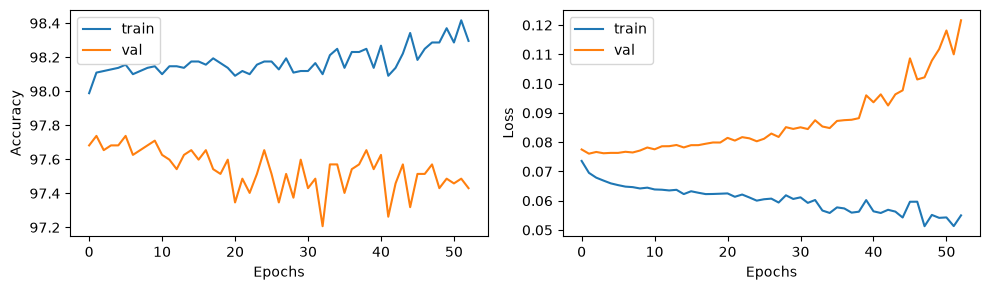

In [55]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))
axes[0].plot(training_history['accuracy'], label='train')
axes[0].plot(validation_history['accuracy'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(training_history['loss'], label='train')
axes[1].plot(validation_history['loss'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
fig.tight_layout()

plt.show()

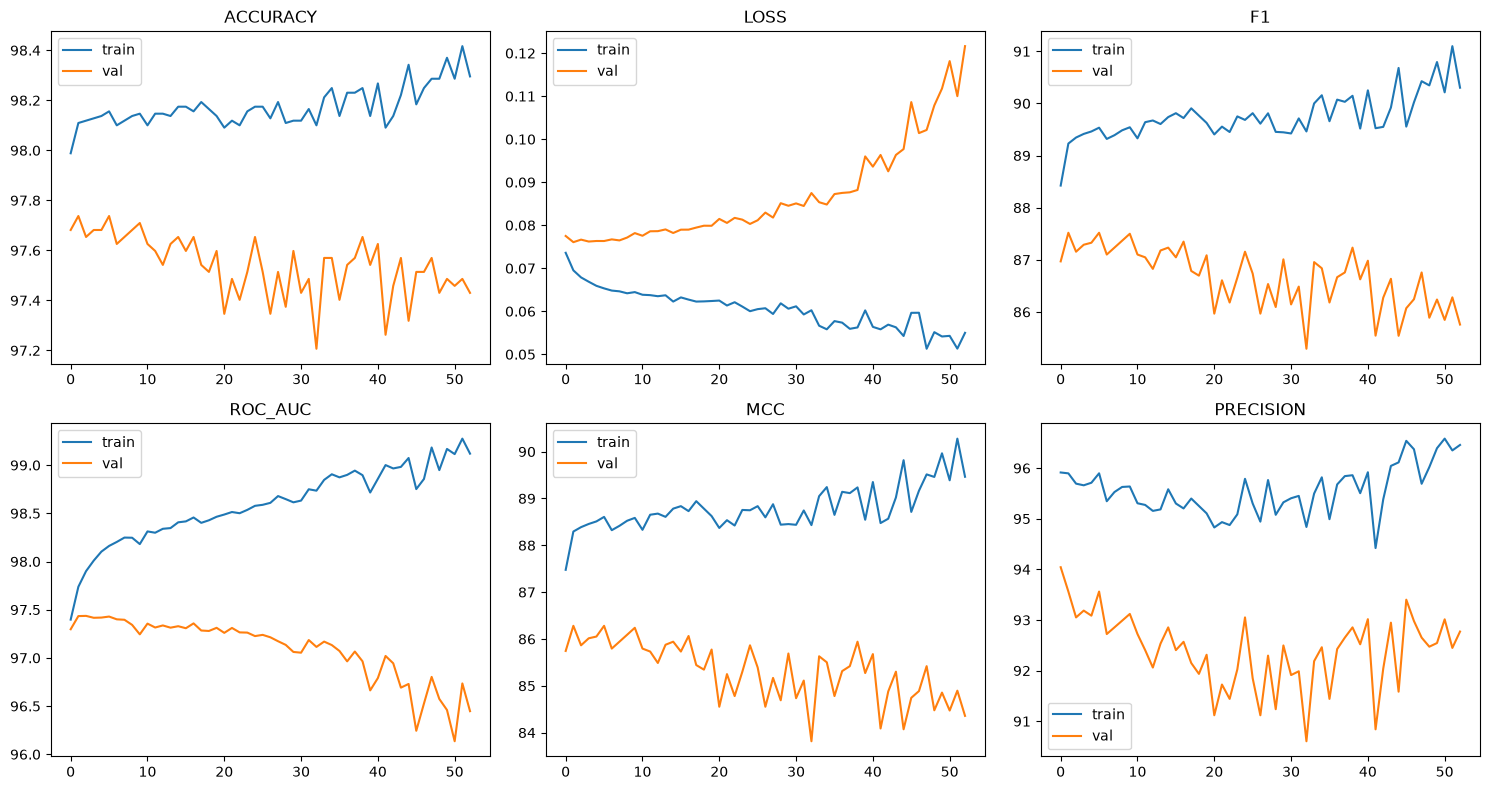

In [56]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics_to_plot = ['accuracy', 'loss', 'f1', 'roc_auc', 'mcc', 'precision']
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    ax.plot(training_history[metric], label='train')
    ax.plot(validation_history[metric], label='val')
    ax.set_title(metric.upper())
    ax.legend()
plt.tight_layout()
plt.show()

In [57]:
# saved models
!ls models

best_Drop.pt
best_Early.pt
best_L2.pt


In [58]:
criterion = nn.CrossEntropyLoss() # same criterion used while training

In [59]:
# assicurati di avere il repo in sys.path e di rimuovere i moduli caricati
import sys, os
repo_path = r'C:\Users\david\RuleTree'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
for _m in list(sys.modules):
    if _m == 'RuleTree' or _m.startswith('RuleTree.'):
        del sys.modules[_m]

In [60]:
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    classification_report,
    roc_auc_score
)

def evaluate_final(model, test_loader, device):
    model.eval()
    predictions = []
    targets_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, pred = torch.max(outputs, 1)
            predictions.extend(pred.cpu().numpy())
            targets_list.extend(targets.cpu().numpy())
    
    y_pred = np.array(predictions)
    y_test = np.array(targets_list)
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
        'f1_weighted': f1_score(y_test, y_pred, average='weighted'),
        'precision_macro': precision_score(y_test, y_pred, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, average='macro'),
        'roc_auc': roc_auc_score(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred, target_names=['0', '1'])
    }
    return metrics, y_pred

In [61]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [62]:
pip install tqdm


Note: you may need to restart the kernel to use updated packages.


In [63]:
# reinitialize models indentical to training to then load the state saved by pytorch ignite
best_NOREG_model = CustomModel(input_size, hidden_size1, hidden_size2, output_size)
best_NOREG_model.load_state_dict(torch.load('models/best_Early.pt'))

best_L2_model = L2Model(input_size, hidden_dim, n_classes)
best_L2_model.load_state_dict(torch.load('models/best_L2.pt'))

best_DROP_model = DropoutModel(input_size, hidden_dim, n_classes, dropout_prob=0.1)
best_DROP_model.load_state_dict(torch.load('models/best_Drop.pt'))

models = {
    'NOREG': best_NOREG_model,
    'L2': best_L2_model,
    'DROP': best_DROP_model
}

results = []
for name, model in models.items():
    metrics, y_pred = evaluate_final(model, test_loader, device)
    # Aggiungi il nome e le metriche principali
    results.append({
        'Modello': name,
        'Accuracy': metrics['accuracy'],
        'F1-macro': metrics['f1_macro'],
        'F1-weighted': metrics['f1_weighted'],
        'Precision-macro': metrics['precision_macro'],
        'Recall-macro': metrics['recall_macro'],
        'ROC-AUC': metrics['roc_auc']
    })
    # Stampa il classification report per ogni modello (opzionale)
    print(f"\n--- {name} ---")
    print(metrics['classification_report'])
    
    # importa la classe direttamente dal file
    from RuleTree.tree.TrepanClassifier import TrepanClassifier
    
    trepan_clf = TrepanClassifier(estimator = model, s_min=100, random_state=42)
    
    trepan_clf.fit(X_train, y_train)
    y_pred_trepan = trepan_clf.predict(X_test)
    y_pred = trepan_clf.oracle.predict(X_test)
    print("Traduzione Trepan")
    print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
    print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
    print(classification_report(y_test, y_pred_trepan))
    fidelty = accuracy_score(y_pred, y_pred_trepan)
    print("Fidelity of Trepan to the original model:", fidelty)


--- NOREG ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.94      0.86      0.90       328

    accuracy                           0.98      3580
   macro avg       0.96      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580



C:\Users\david\AppData\Local\Temp\ipykernel_26232\2695327207.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_NOREG_model.load_state_dict(torch.load('models/best_Ear

Traduzione Trepan
Accuracy 0.979608938547486
F1-score [0.98882254 0.88394277]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3252
           1       0.92      0.85      0.88       328

    accuracy                           0.98      3580
   macro avg       0.95      0.92      0.94      3580
weighted avg       0.98      0.98      0.98      3580

Fidelity of Trepan to the original model: 0.9879888268156425

--- L2 ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.93      0.87      0.90       328

    accuracy                           0.98      3580
   macro avg       0.96      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580

Traduzione Trepan
Accuracy 0.9804469273743017
F1-score [0.98925061 0.89197531]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
       

In [64]:
df_results = pd.DataFrame(results)
print("\nConfronto modelli:")
print(df_results.to_string(index=False, float_format="%.4f"))


Confronto modelli:
Modello  Accuracy  F1-macro  F1-weighted  Precision-macro  Recall-macro  ROC-AUC
  NOREG    0.9821    0.9440       0.9817           0.9643        0.9257   0.9257
     L2    0.9821    0.9445       0.9818           0.9604        0.9299   0.9299
   DROP    0.9802    0.9392       0.9800           0.9487        0.9301   0.9301


# HyperParameter-Tuning

In [65]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import RandomizedSearchCV
from ignite.engine import State

In [66]:
class PyTorchModel(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, activation):
        super(PyTorchModel, self).__init__()
        layers = []
        prev_size = input_dim
        
        # create linear layers with specified hidden layer sizes
        for size in hidden_layer_sizes:
            layers.append(nn.Linear(prev_size, size))
            layers.append(activation)
            prev_size = size
        
        # final output layer
        layers.append(nn.Linear(prev_size, n_classes))
        
        # sequentially stack all layers
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        # pass input through all layers and apply softmax activation
        #return torch.softmax(self.layers(x), dim=-1)
        return self.layers(x)

In [67]:
class PyTorchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        input_dim,
        hidden_layer_sizes,
        activation='relu',        # 'relu' o 'tanh'
        optimizer='adam',         # 'adam' o 'sgd'
        lr=0.001,
        epochs=50,
        batch_size=32,
        # parametri opzionali per Ignite (non saranno clonati)
        device=None,
        criterion=None,
        metrics=None,
    ):
        # Solo tipi base / serializzabili
        self.input_dim = input_dim
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.optimizer = optimizer
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size

        # Opzionali: se non passati, verranno creati in fit()
        self.device = device
        self.criterion = criterion
        self.metrics = metrics

        # Attributi interni (non clonabili) – verranno riempiti in fit()
        self.model = None
        self.optimizer_obj = None
        self.trainer = None
        self.train_loader = None
        self.classes_ = None

    # ---------------------------------------------------------
    # Metodi interni per costruire oggetti PyTorch/Ignite
    # ---------------------------------------------------------
    def _get_activation(self):
        if self.activation == 'relu':
            return nn.ReLU()
        elif self.activation == 'tanh':
            return nn.Tanh()
        else:
            raise ValueError("activation must be 'relu' or 'tanh'")

    def _get_optimizer_class(self):
        if self.optimizer == 'adam':
            return optim.Adam
        elif self.optimizer == 'sgd':
            return optim.SGD
        else:
            raise ValueError("optimizer must be 'adam' or 'sgd'")

    def _build_model(self):
        activation_fn = self._get_activation()
        return PyTorchModel(self.input_dim, self.hidden_layer_sizes, activation_fn)

    def _build_optimizer(self, model_params):
        opt_class = self._get_optimizer_class()
        return opt_class(model_params, lr=self.lr)

    # ---------------------------------------------------------
    # Metodi di scikit-learn
    # ---------------------------------------------------------
    def fit(self, X, y):
        # Imposta il device
        if self.device is None:
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Crea criterion e metrics se non forniti
        if self.criterion is None:
            self.criterion = nn.CrossEntropyLoss()
        if self.metrics is None:
            self.metrics = {"accuracy": Accuracy(), "loss": Loss(self.criterion)}

        # Salva le classi (richiesto da BaseEstimator)
        self.classes_ = np.unique(y)

        # Costruisce modello e ottimizzatore
        self.model = self._build_model().to(self.device)
        self.optimizer_obj = self._build_optimizer(self.model.parameters())

        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        elif isinstance(y, list):
            y = np.array(y)
        # Prepara DataLoader
        tensor_dataset = TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.long)
        )
        self.train_loader = DataLoader(
            tensor_dataset,
            batch_size=self.batch_size,
            shuffle=True
        )

        # Crea trainer e evaluator con Ignite
        self.trainer = create_supervised_trainer(
            self.model, self.optimizer_obj, self.criterion, self.device
        )

        # (Opzionale) Log della loss ogni 10 iterazioni
        @self.trainer.on(Events.ITERATION_COMPLETED(every=10))
        def log_loss(engine):
            print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.4f}")

        # Aggiungi log a fine epoca
        @self.trainer.on(Events.EPOCH_COMPLETED)
        def log_epoch(engine):
            # Calcola accuracy e loss sul training set (senza creare un evaluator separato)
            self.model.eval()
            total_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for inputs, targets in self.train_loader:
                    inputs, targets = inputs.to(self.device), targets.to(self.device)
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, targets)
                    total_loss += loss.item()
                    _, predicted = torch.max(outputs, 1)
                    total += targets.size(0)
                    correct += (predicted == targets).sum().item()
            accuracy = 100 * correct / total
            avg_loss = total_loss / len(self.train_loader)
            print(f"Training Results - Epoch[{engine.state.epoch}] Avg accuracy: {accuracy:.2f}% Avg loss: {avg_loss:.4f}")

        # Avvia l'addestramento
        self.trainer.run(self.train_loader, max_epochs=self.epochs)

        return self

    def predict(self, X):
        if self.model is None:
            raise RuntimeError("Model not fitted yet. Call fit() first.")

        self.model.eval()
        data_loader = DataLoader(
            TensorDataset(torch.tensor(X, dtype=torch.float32)),
            batch_size=self.batch_size,
            shuffle=False
        )
        predictions = []
        with torch.no_grad():
            for inputs, in data_loader:
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                _, pred = torch.max(outputs, 1)
                predictions.extend(pred.cpu().numpy())
        return np.array(predictions)

In [68]:
param_grid = {
    'hidden_layer_sizes': [(128, 64, 32), (64, 32, 16), (256, 128, 64)],
    'activation': ['relu', 'tanh'],
    'lr': [0.001, 0.01, 0.1, 1],
    'optimizer': ['adam', 'sgd'],
    'epochs': [10, 50, 100, 200],
    'batch_size': [32, 64, 128]
}

In [69]:
clf = PyTorchClassifier(
    input_dim=input_size,
    hidden_layer_sizes=(128, 64),
    activation='relu',
    optimizer='adam',
    lr=0.001,
    epochs=50,
    batch_size=32,
    device=device
)

In [70]:
# perform randomized grid search
rs = RandomizedSearchCV(clf, param_grid, scoring='f1_macro', verbose=True, n_iter=10, cv=3, error_score='raise')

In [71]:
import sklearn
sklearn.set_config(display='text')

In [72]:
rs.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Epoch[1], Iter[10] Loss: 0.1711
Epoch[1], Iter[20] Loss: 0.3538
Epoch[1], Iter[30] Loss: 0.1398
Epoch[1], Iter[40] Loss: 0.1758
Epoch[1], Iter[50] Loss: 0.2284
Epoch[1], Iter[60] Loss: 0.1592
Epoch[1], Iter[70] Loss: 0.0688
Epoch[1], Iter[80] Loss: 0.1820
Epoch[1], Iter[90] Loss: 0.4679
Epoch[1], Iter[100] Loss: 0.0170
Epoch[1], Iter[110] Loss: 0.0379
Epoch[1], Iter[120] Loss: 0.1158
Epoch[1], Iter[130] Loss: 0.2201
Epoch[1], Iter[140] Loss: 0.1563
Epoch[1], Iter[150] Loss: 0.1019
Epoch[1], Iter[160] Loss: 0.0514
Epoch[1], Iter[170] Loss: 0.0686
Epoch[1], Iter[180] Loss: 0.7426
Epoch[1], Iter[190] Loss: 0.0232
Epoch[1], Iter[200] Loss: 0.2780
Epoch[1], Iter[210] Loss: 0.0728
Epoch[1], Iter[220] Loss: 0.0150
Training Results - Epoch[1] Avg accuracy: 97.64% Avg loss: 0.0978
Epoch[2], Iter[230] Loss: 0.0012
Epoch[2], Iter[240] Loss: 0.1633
Epoch[2], Iter[250] Loss: 0.0389
Epoch[2], Iter[260] Loss: 0.0650
Epoch[2], Iter[270] Loss

RandomizedSearchCV(cv=3, error_score='raise',
                   estimator=PyTorchClassifier(device='cpu',
                                               hidden_layer_sizes=(128, 64),
                                               input_dim=8),
                   param_distributions={'activation': ['relu', 'tanh'],
                                        'batch_size': [32, 64, 128],
                                        'epochs': [10, 50, 100, 200],
                                        'hidden_layer_sizes': [(128, 64, 32),
                                                               (64, 32, 16),
                                                               (256, 128, 64)],
                                        'lr': [0.001, 0.01, 0.1, 1],
                                        'optimizer': ['adam', 'sgd']},
                   scoring='f1_macro', verbose=True)

In [73]:
print(rs.best_score_, rs.best_params_)

0.9360297980579665 {'optimizer': 'sgd', 'lr': 1, 'hidden_layer_sizes': (128, 64, 32), 'epochs': 10, 'batch_size': 128, 'activation': 'relu'}


In [74]:
y_pred = rs.predict(X_test).astype(int)
y_pred_train = rs.predict(X_train).astype(int)
print('Accuracy %s' % accuracy_score(y_train, y_pred_train))
print('F1-score %s' % f1_score(y_train, y_pred_train, average=None))
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9806277358666294
F1-score [0.98937583 0.89029536]
Accuracy 0.982122905027933
F1-score [0.99017501 0.90092879]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.92      0.89      0.90       328

    accuracy                           0.98      3580
   macro avg       0.95      0.94      0.95      3580
weighted avg       0.98      0.98      0.98      3580



In [75]:
class CustomModel_3layers(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, hidden_size3, output_size):
        super(CustomModel_3layers, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, hidden_size3)
        self.fc4 = nn.Linear(hidden_size3, output_size)
        self.tanh = nn.Tanh()
        #self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.fc4(x)
        return x

In [76]:
# define hyperparameters
#n_classes = len(np.unique(y_train))
#input_size = X_train.shape[1]
hidden_size1 = 128
hidden_size2 = 64
hidden_size3 = 32
output_size = n_classes

In [77]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [78]:
modelf = CustomModel_3layers(input_size, hidden_size1, hidden_size2, hidden_size3, output_size)

In [79]:
# optimizer and loss function
optimizer = optim.SGD(modelf.parameters(), lr=1)
criterion = nn.CrossEntropyLoss()

In [80]:
# ignite trainer
trainer = create_supervised_trainer(modelf, optimizer, criterion, device)

# ignite train and validation evaluators
train_evaluator = create_supervised_evaluator(modelf, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(modelf, metrics=val_metrics, device=device)

# Crea le history con tutte le chiavi delle metriche (più 'loss' che è già presente)
training_history = {key: [] for key in val_metrics.keys()}
validation_history = {key: [] for key in val_metrics.keys()}

In [81]:
@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    # Salva ogni metrica nella history (accuracy e f1 in percentuale, loss no)
    for key, value in metrics.items():
        if key != 'loss':
            training_history[key].append(value * 100)
        else:
            training_history[key].append(value)
    # Stampa a schermo (scegli le metriche più importanti)
    print(f"Training Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    for key, value in metrics.items():
        if key != 'loss':
            validation_history[key].append(value * 100)
        else:
            validation_history[key].append(value)
    print(f"Validation Results - Epoch[{trainer.state.epoch}] "
          f"Acc: {metrics['accuracy']:.2f}%  Loss: {metrics['loss']:.4f}  "
          f"F1: {metrics['f1']:.4f}  ROC_AUC: {metrics['roc_auc']:.4f}  "
          f"MCC: {metrics['mcc']:.4f}  Prec: {metrics['precision']:.4f}  "
          f"Rec: {metrics['recall']:.4f}")

best_f1 = 0.0
best_path = 'models/best_randoms.pt'

@val_evaluator.on(Events.EPOCH_COMPLETED)
def save_best_model(engine):
    global best_f1
    f1 = engine.state.metrics['f1']
    if f1 > best_f1:
        best_f1 = f1
        torch.save(modelf.state_dict(), best_path)
        print(f"✅ Nuovo miglior modello salvato (F1-macro: {f1:.4f} all'epoca {trainer.state.epoch})")

In [82]:
# define early stopping and model checkpoint
handler = EarlyStopping(patience=15, score_function=score_function, trainer=trainer)



# Attach early stopping and model checkpoint to the trainer
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)

In [83]:
trainer.run(train_loader, max_epochs=150)

Training Results - Epoch[1] Acc: 0.98%  Loss: 0.0782  F1: 0.8828  ROC_AUC: 0.9710  MCC: 0.8738  Prec: 0.9622  Rec: 0.9130
✅ Nuovo miglior modello salvato (F1-macro: 0.8683 all'epoca 1)
Validation Results - Epoch[1] Acc: 0.98%  Loss: 0.0824  F1: 0.8683  ROC_AUC: 0.9702  MCC: 0.8559  Prec: 0.9390  Rec: 0.9172
Epoch[2], Iter[100] Loss: 0.0817
Training Results - Epoch[2] Acc: 0.98%  Loss: 0.0742  F1: 0.8878  ROC_AUC: 0.9743  MCC: 0.8785  Prec: 0.9597  Rec: 0.9197
✅ Nuovo miglior modello salvato (F1-macro: 0.8705 all'epoca 2)
Validation Results - Epoch[2] Acc: 0.98%  Loss: 0.0789  F1: 0.8705  ROC_AUC: 0.9728  MCC: 0.8581  Prec: 0.9382  Rec: 0.9201
Epoch[3], Iter[200] Loss: 0.0736
Training Results - Epoch[3] Acc: 0.98%  Loss: 0.0719  F1: 0.8922  ROC_AUC: 0.9746  MCC: 0.8826  Prec: 0.9572  Rec: 0.9260
✅ Nuovo miglior modello salvato (F1-macro: 0.8729 all'epoca 3)
Validation Results - Epoch[3] Acc: 0.98%  Loss: 0.0788  F1: 0.8729  ROC_AUC: 0.9728  MCC: 0.8602  Prec: 0.9319  Rec: 0.9283
Epoch[4

2026-08-26 20:01:56,738 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Training Results - Epoch[40] Acc: 0.98%  Loss: 0.0646  F1: 0.8945  ROC_AUC: 0.9825  MCC: 0.8844  Prec: 0.9508  Rec: 0.9338
Validation Results - Epoch[40] Acc: 0.98%  Loss: 0.0762  F1: 0.8713  ROC_AUC: 0.9743  MCC: 0.8582  Prec: 0.9222  Rec: 0.9361


State:
	iteration: 3360
	epoch: 40
	epoch_length: 84
	max_epochs: 150
	max_iters: <class 'NoneType'>
	output: 0.028370603919029236
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

In [84]:
modelf.load_state_dict(torch.load('models/best_randoms.pt'))

<All keys matched successfully>

In [85]:
metrics, y_pred = evaluate_final(modelf, test_loader, device)
name = "Best_randomized"
 # Aggiungi il nome e le metriche principali
results.append({
        'Modello': name,
        'Accuracy': metrics['accuracy'],
        'F1-macro': metrics['f1_macro'],
        'F1-weighted': metrics['f1_weighted'],
        'Precision-macro': metrics['precision_macro'],
        'Recall-macro': metrics['recall_macro'],
        'ROC-AUC': metrics['roc_auc']
})
# Stampa il classification report per ogni modello (opzionale)
print(f"\n--- {name} ---")
print(metrics['classification_report'])


--- Best_randomized ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.94      0.86      0.90       328

    accuracy                           0.98      3580
   macro avg       0.96      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580



In [95]:
trepan_clf = TrepanClassifier(estimator = modelf, s_min=300, max_depth=5, max_leaf_nodes = 8 , prune_useless_leaves=True)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
y_pred = trepan_clf.oracle.predict(X_test)
print("Traduzione Trepan")
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)

Traduzione Trepan
Accuracy 0.9807262569832402
F1-score [0.98942529 0.89133858]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.92      0.86      0.89       328

    accuracy                           0.98      3580
   macro avg       0.95      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580

Fidelity of Trepan to the original model: 0.9921787709497206


In [96]:
attributes = [col for col in X.columns]
trepan_clf.print_trepan_rules(feature_names=attributes)




  REGOLE GLOBALI ESTRATTE DA TREPAN
REGOLA 1 [Nodo ID: Rll]:
  IF  (ip_kurtosis <= 0.663) AND 
      (ip_kurtosis <= 0.474)
  THEN Predizione = 0
  [Fedeltà: 99.90%, Copertura: 90.86%]

REGOLA 2 [Nodo ID: Rlrl]:
  IF  (ip_kurtosis <= 0.663) AND 
      (ip_kurtosis > 0.474) AND 
      (dm_std <= 0.602)
  THEN Predizione = 0
  [Fedeltà: 86.75%, Copertura: 0.77%]

REGOLA 3 [Nodo ID: Rlrr]:
  IF  (ip_kurtosis <= 0.663) AND 
      (ip_kurtosis > 0.474) AND 
      (dm_std > 0.602)
  THEN Predizione = 1
  [Fedeltà: 67.65%, Copertura: 0.32%]

REGOLA 4 [Nodo ID: Rrl]:
  IF  (ip_kurtosis > 0.663) AND 
      (dm_std <= -0.492)
  THEN Predizione = 0
  [Fedeltà: 68.42%, Copertura: 0.18%]

REGOLA 5 [Nodo ID: Rrr]:
  IF  (ip_kurtosis > 0.663) AND 
      (dm_std > -0.492)
  THEN Predizione = 1
  [Fedeltà: 98.58%, Copertura: 7.87%]



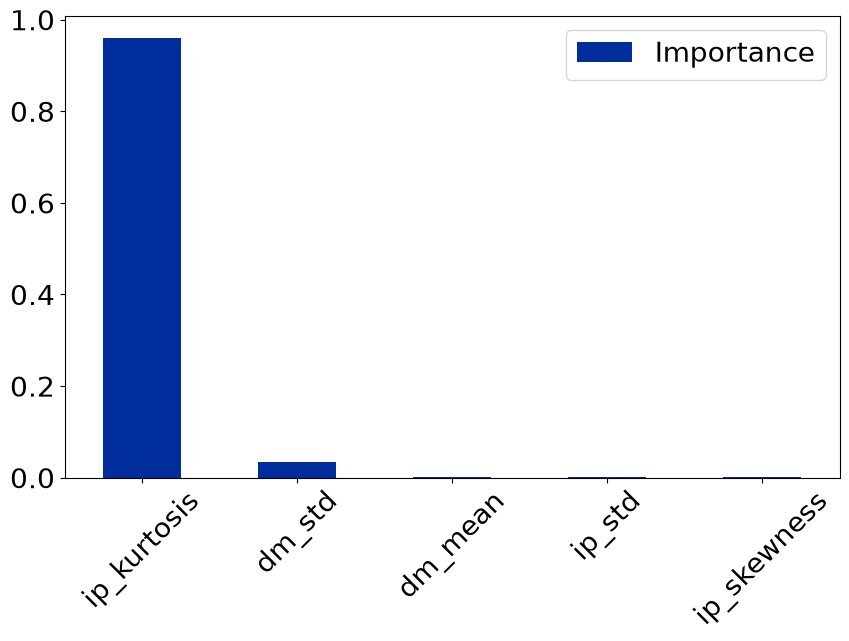

In [88]:
import pandas as pd
feature_importances = trepan_clf.compute_feature_importances()
feature_names = attributes
if len(feature_importances) < len(feature_names):
    padded_importances = np.zeros(len(feature_names))
    padded_importances[:len(feature_importances)] = feature_importances
    feature_importances = padded_importances



# 2. Ora la creazione del DataFrame Pandas filmerà liscia senza errori
feat_importances = pd.DataFrame(feature_importances, index=feature_names, columns=["Importance"])
feat_importances.sort_values(by='Importance', ascending=False, inplace=True)
feat_importances.head(5).plot(kind='bar', figsize=(10,6), color = '#002d9c')
plt.xticks(fontsize=20, rotation = 45)
plt.yticks(fontsize=20)                       
plt.legend(fontsize=20)  
plt.show()